In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
from pyunpack import Archive

# ===============================
# 0. Mount Drive & Extract Dataset
# ===============================
from google.colab import drive
drive.mount('/content/drive')

!apt install unrar
!pip install pyunpack patool

rar_path = '/content/drive/MyDrive/Colab Dataset/data.rar'
extract_path = '/content/Dataset'
os.makedirs(extract_path, exist_ok=True)
Archive(rar_path).extractall(extract_path)

# ===============================
# 1. Dataset Paths
# ===============================
data_root = '/content/Dataset/data/Recognition'
train_dir = os.path.join(data_root, 'train')
val_dir   = os.path.join(data_root, 'validation')
test_dir  = os.path.join(data_root, 'test')

# ===============================
# 2. Load Datasets
# ===============================
image_size = (224, 224)  # DenseNet121 standard
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=True, seed=seed
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=False, seed=seed
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# ===============================
# 3. Prefetch for Performance
# ===============================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
Found 26097 files belonging to 9 classes.
Found 1634 files belonging to 9 classes.
Found 1144 files belonging to 9 classes.
Classes: ['1000_taka', '100_taka', '10_taka', '200_taka', '20_taka', '2_taka', '500_taka', '50_taka', '5_taka']


In [12]:
!rm -rf "/content/Dataset"

In [14]:
# ===============================
# 3. Prefetch for Performance
# ===============================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# ===============================
# 4. Build DenseNet121 Model (Feature Extraction)
# ===============================
def create_densenet121(input_shape=(224,224,3), num_classes=9):
    base_model = applications.DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False  # freeze for initial training

    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(1./255)(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="DenseNet121_Currency")
    return model

model = create_densenet121(input_shape=(224,224,3), num_classes=num_classes)
model.summary()

# ===============================
# 5. Compile
# ===============================
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ===============================
# 6. Callbacks
# ===============================
checkpoint_path = "best_densenet121_currency.h5"
callbacks = [
    keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

Model: "DenseNet121_Currency"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,302,217 (27.86 MB)

 Trainable params: 264,713 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [15]:

# ===============================
# 7. Initial Training (Feature Extraction)
# ===============================
epochs = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3639 - loss: 1.8147
Epoch 1: val_loss improved from inf to 0.72163, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 149s 147ms/step - accuracy: 0.3641 - loss: 1.8142 - val_accuracy: 0.8213 - val_loss: 0.7216 - learning_rate: 1.0000e-04
Epoch 2/20
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7251 - loss: 0.8657
Epoch 2: val_loss improved from 0.72163 to 0.43137, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 70s 80ms/step - accuracy: 0.7252 - loss: 0.8655 - val_accuracy: 0.9027 - val_loss: 0.4314 - learning_rate: 1.0000e-04
Epoch 3/20
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8195 - loss: 0.5978
Epoch 3: val_loss improved from 0.43137 to 0.31240, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 63s 77ms/step - accuracy: 0.8195 - loss: 0.5977 - val_accuracy: 0.9321 - val_loss: 0.3124 - learning_rate: 1.0000e-04
Epoch 4/20
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8608 - loss: 0.4623
Epoch 4: val_loss improved from 0.31240 to 0.24899, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 78ms/step - accuracy: 0.8608 - loss: 0.4623 - val_accuracy: 0.9406 - val_loss: 0.2490 - learning_rate: 1.0000e-04
Epoch 5/20
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8913 - loss: 0.3732
Epoch 5: val_loss improved from 0.24899 to 0.20210, saving model to best_densenet121_currency.h5


...

816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 80ms/step - accuracy: 0.9657 - loss: 0.1219 - val_accuracy: 0.9761 - val_loss: 0.0785 - learning_rate: 1.0000e-04
Epoch 16/20
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9683 - loss: 0.1111
Epoch 16: val_loss did not improve from 0.07854
816/816 ━━━━━━━━━━━━━━━━━━━━ 79s 77ms/step - accuracy: 0.9683 - loss: 0.1111 - val_accuracy: 0.9774 - val_loss: 0.0788 - learning_rate: 1.0000e-04
Epoch 17/20
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9722 - loss: 0.1025
Epoch 17: val_loss improved from 0.07854 to 0.07470, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 83s 78ms/step - accuracy: 0.9722 - loss: 0.1025 - val_accuracy: 0.9786 - val_loss: 0.0747 - learning_rate: 1.0000e-04
Epoch 18/20
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9737 - loss: 0.0940
Epoch 18: val_loss improved from 0.07470 to 0.07411, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 83s 79ms/step - accuracy: 0.9737 - loss: 0.0940 - val_accuracy: 0.9755 - val_loss: 0.0741 - learning_rate: 1.0000e-04
Epoch 19/20
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9768 - loss: 0.0891
Epoch 19: val_loss improved from 0.07411 to 0.07082, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.9768 - loss: 0.0891 - val_accuracy: 0.9767 - val_loss: 0.0708 - learning_rate: 1.0000e-04
Epoch 20/20
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9775 - loss: 0.0836
Epoch 20: val_loss improved from 0.07082 to 0.06461, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 81s 78ms/step - accuracy: 0.9775 - loss: 0.0836 - val_accuracy: 0.9823 - val_loss: 0.0646 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 20.


In [16]:
# ===============================
# 8. Fine-Tuning DenseNet121
# ===============================
# Unfreeze last 50 layers
model.trainable = True
for layer in model.layers[:-50]:
    layer.trainable = False

# Compile with lower learning rate for fine-tuning
optimizer_ft = keras.optimizers.Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer_ft,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train again for fine-tuning
fine_tune_epochs = 15
total_epochs = epochs + fine_tune_epochs

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    callbacks=callbacks
)

# Save fine-tuned model
model.save("DenseNet121_Bangla_Currency_FineTuned.h5")

Epoch 20/35
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9803 - loss: 0.0727
Epoch 20: val_loss improved from 0.06461 to 0.06179, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 121s 119ms/step - accuracy: 0.9803 - loss: 0.0727 - val_accuracy: 0.9804 - val_loss: 0.0618 - learning_rate: 1.0000e-05
Epoch 21/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9822 - loss: 0.0694
Epoch 21: val_loss improved from 0.06179 to 0.06040, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 97s 78ms/step - accuracy: 0.9822 - loss: 0.0694 - val_accuracy: 0.9804 - val_loss: 0.0604 - learning_rate: 1.0000e-05
Epoch 22/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9812 - loss: 0.0701
Epoch 22: val_loss did not improve from 0.06040
816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.9812 - loss: 0.0701 - val_accuracy: 0.9798 - val_loss: 0.0604 - learning_rate: 1.0000e-05
Epoch 23/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9833 - loss: 0.0677
Epoch 23: val_loss did not improve from 0.06040
816/816 ━━━━━━━━━━━━━━━━━━━━ 65s 80ms/step - accuracy: 0.9833 - loss: 0.0677 - val_accuracy: 0.9798 - val_loss: 0.0609 - learning_rate: 1.0000e-05
Epoch 24/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9813 - loss: 0.0687
Epoch 24: val_loss improved from 0.06040 to 0.05989, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 80ms/step - accuracy: 0.9813 - loss: 0.0687 - val_accuracy: 0.9786 - val_loss: 0.0599 - learning_rate: 1.0000e-05
Epoch 25/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9829 - loss: 0.0691
Epoch 25: val_loss improved from 0.05989 to 0.05930, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 83s 82ms/step - accuracy: 0.9829 - loss: 0.0691 - val_accuracy: 0.9792 - val_loss: 0.0593 - learning_rate: 1.0000e-05
Epoch 26/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9821 - loss: 0.0679
Epoch 26: val_loss did not improve from 0.05930
816/816 ━━━━━━━━━━━━━━━━━━━━ 79s 78ms/step - accuracy: 0.9821 - loss: 0.0679 - val_accuracy: 0.9804 - val_loss: 0.0596 - learning_rate: 1.0000e-05
Epoch 27/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9823 - loss: 0.0659
Epoch 27: val_loss did not improve from 0.05930
816/816 ━━━━━━━━━━━━━━━━━━━━ 63s 77ms/step - accuracy: 0.9823 - loss: 0.0659 - val_accuracy: 0.9804 - val_loss: 0.0597 - learning_rate: 1.0000e-05
Epoch 28/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9830 - loss: 0.0658
Epoch 28: val_loss improved from 0.05930 to 0.05848, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 85s 80ms/step - accuracy: 0.9830 - loss: 0.0658 - val_accuracy: 0.9798 - val_loss: 0.0585 - learning_rate: 1.0000e-05
Epoch 29/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9826 - loss: 0.0655
Epoch 29: val_loss did not improve from 0.05848
816/816 ━━━━━━━━━━━━━━━━━━━━ 80s 78ms/step - accuracy: 0.9826 - loss: 0.0655 - val_accuracy: 0.9804 - val_loss: 0.0590 - learning_rate: 1.0000e-05
Epoch 30/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9833 - loss: 0.0660
Epoch 30: val_loss did not improve from 0.05848
816/816 ━━━━━━━━━━━━━━━━━━━━ 81s 78ms/step - accuracy: 0.9833 - loss: 0.0660 - val_accuracy: 0.9810 - val_loss: 0.0587 - learning_rate: 1.0000e-05
Epoch 31/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9834 - loss: 0.0650
Epoch 31: val_loss improved from 0.05848 to 0.05815, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 83s 79ms/step - accuracy: 0.9834 - loss: 0.0650 - val_accuracy: 0.9804 - val_loss: 0.0582 - learning_rate: 1.0000e-05
Epoch 32/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9856 - loss: 0.0619
Epoch 32: val_loss did not improve from 0.05815
816/816 ━━━━━━━━━━━━━━━━━━━━ 64s 78ms/step - accuracy: 0.9856 - loss: 0.0619 - val_accuracy: 0.9798 - val_loss: 0.0582 - learning_rate: 1.0000e-05
Epoch 33/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9851 - loss: 0.0614
Epoch 33: val_loss did not improve from 0.05815
816/816 ━━━━━━━━━━━━━━━━━━━━ 83s 80ms/step - accuracy: 0.9851 - loss: 0.0614 - val_accuracy: 0.9810 - val_loss: 0.0582 - learning_rate: 1.0000e-05
Epoch 34/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9848 - loss: 0.0604
Epoch 34: val_loss improved from 0.05815 to 0.05745, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 81s 79ms/step - accuracy: 0.9848 - loss: 0.0604 - val_accuracy: 0.9816 - val_loss: 0.0575 - learning_rate: 1.0000e-05
Epoch 35/35
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9850 - loss: 0.0608
Epoch 35: val_loss did not improve from 0.05745
816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.9850 - loss: 0.0608 - val_accuracy: 0.9810 - val_loss: 0.0578 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 34.


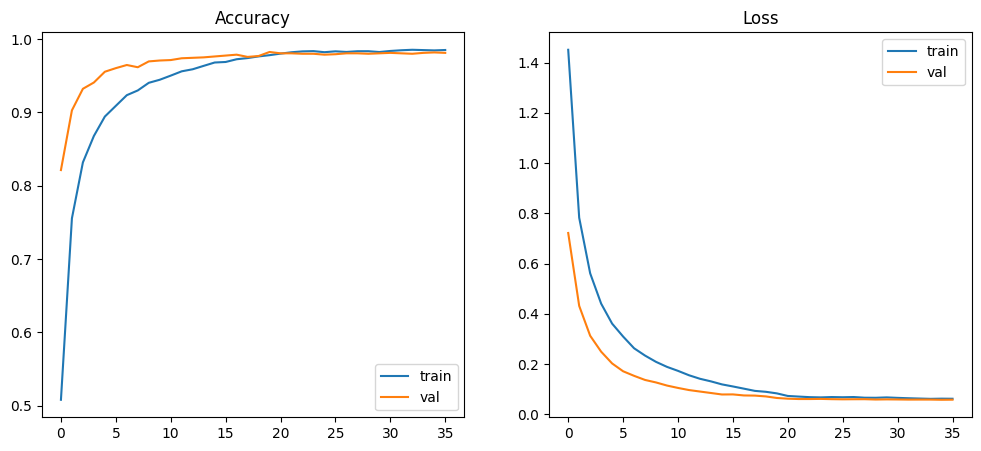

In [17]:
# ===============================
# 9. Plot Training & Fine-Tuning History
# ===============================
acc = history.history['accuracy'] + history_ft.history['accuracy']
val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']
loss = history.history['loss'] + history_ft.history['loss']
val_loss = history.history['val_loss'] + history_ft.history['val_loss']

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(acc, label='train')
plt.plot(val_acc, label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss, label='train')
plt.plot(val_loss, label='val')
plt.title('Loss')
plt.legend()
plt.show()

In [18]:
# ===============================
# 10. Evaluate on Test Data
# ===============================
y_true, y_pred = [], []

for batch_images, batch_labels in test_ds:
    preds = model.predict(batch_images)
    preds_classes = np.argmax(preds, axis=1)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(preds_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

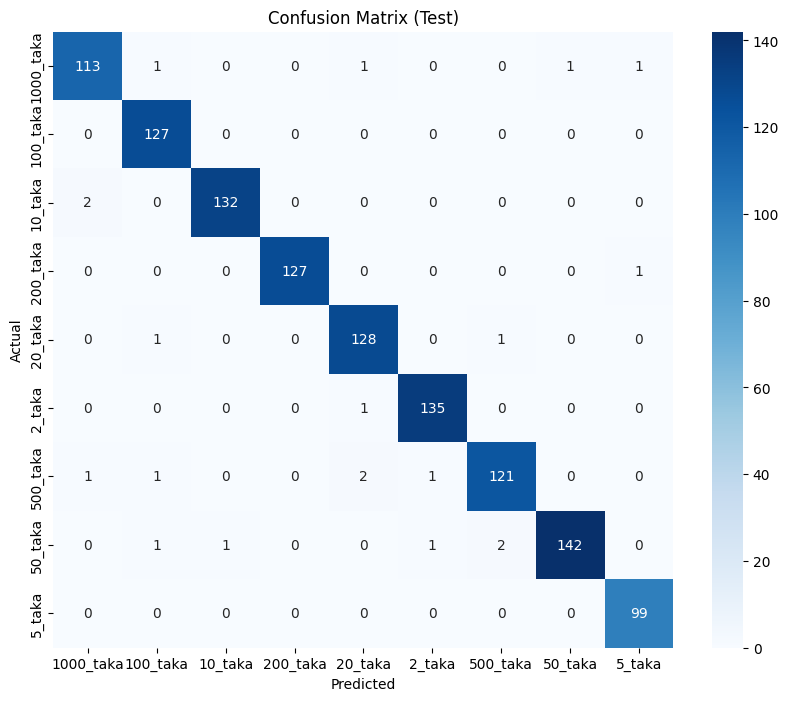

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test)')
plt.show()

In [20]:
# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

   1000_taka       0.97      0.97      0.97       117
    100_taka       0.97      1.00      0.98       127
     10_taka       0.99      0.99      0.99       134
    200_taka       1.00      0.99      1.00       128
     20_taka       0.97      0.98      0.98       130
      2_taka       0.99      0.99      0.99       136
    500_taka       0.98      0.96      0.97       126
     50_taka       0.99      0.97      0.98       147
      5_taka       0.98      1.00      0.99        99

    accuracy                           0.98      1144
   macro avg       0.98      0.98      0.98      1144
weighted avg       0.98      0.98      0.98      1144

